In [41]:
from ngsolve import *
from netgen.geom2d import CSG2d, Circle, Rectangle
from netgen.geom2d import SplineGeometry
geo = SplineGeometry()

In [42]:
def axi_coil(rbox : float = 0.1,
                  rcoil1: float = 0.01,
                  rcoil2: float = 0.02,
                  zcoil : float = 0.02,
                  maxh_in : float = 0.001,
                  maxh_ext : float = 0.005,
                  xinit = 0,
                  air_label = "air",
                  coil_label = "coil",
                  ext_label = "ext",
                  bot_label = "bot",
                  axis_label = "axis") -> Mesh:
    """ half  """
    air = 1
    coil = 2
    
    geo = SplineGeometry()
    
    pnts =[[(xinit,0), {"maxh": maxh_in}],
            [(rcoil1, 0), {"maxh": maxh_in}],
            [(rcoil2, 0), {"maxh": maxh_in}],
            [(rbox, 0), {"maxh": maxh_ext}],
            [(rbox, rbox), {"maxh": maxh_ext}],
            [(xinit, rbox), {"maxh": maxh_ext}],
            [(rcoil1, zcoil), {"maxh": maxh_in}],
            [(rcoil2, zcoil), {"maxh": maxh_in}]]
    
    for pnt, props in pnts:
        geo.AppendPoint(*pnt, **props)
    
    lines = [[["line",0,1], {"leftdomain": air, "rightdomain": 0, "bc" : bot_label}],
             [["line",1,2], {"leftdomain": coil, "rightdomain": 0, "bc" : bot_label}],
             [["line",2,3], {"leftdomain": air, "rightdomain": 0, "bc" : bot_label}],
             [["spline3",3,4,5], {"leftdomain": air, "rightdomain": 0, "maxh": maxh_ext, "bc" : ext_label}],
             [["line",5,0], {"leftdomain": air, "rightdomain": 0, "bc" : axis_label}],
             [["line",6,7], {"leftdomain": air, "rightdomain": coil}],
             [["line",1,6], {"leftdomain": air, "rightdomain": coil}],
             [["line",2,7], {"leftdomain": coil, "rightdomain": air}],
            ]
    
    for line, props in lines:
        geo.Append(line, **props)
        
    geo.SetMaterial(air, air_label)
    geo.SetMaterial(coil, coil_label)
    
    return Mesh(geo.GenerateMesh(maxh = max([maxh_in, maxh_ext])))

mesh = axi_coil()

from ngsolve.webgui import Draw
Draw(mesh)

            

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

# Modélisation plane

In [43]:
x.spacedim = mesh.dim

def curl(a, type = "planar"):
    if type == "planar":
        R = CF(((0,1), (-1,0)), dims = (2,2))
        return R * grad(a)
    elif type == "cylindrical":
        # ATTENTION : trièdre direct => z = -y
        return CF((grad(a)[1], # dz => -dy
                   -(grad(x)[0]*a + grad(a)[0]*x) / x) # uz = -uy
                  )

mu0 = 4e-7 * pi
j = 1e6

fes = H1(mesh, order = 1, dirichlet = "ext|axis")
a, v = fes.TnT()

K = BilinearForm(fes)
K += curl(v) * 1/mu0 * curl(a) * dx

f =LinearForm(fes)
f += j*v * dx("coil")

K.Assemble()
f.Assemble()

sol_planar = GridFunction(fes)
sol_planar.vec.data = K.mat.Inverse(fes.FreeDofs()) * f.vec



### Tracé des lignes de champ

On parle plutôt de lignes de flux. Pour trouver leur direction, on peut chercher un potentiel $\psi$ tel que
$$ d\psi = d\vec{\phi} \cdot \vec{n} $$
Alors, si $d\psi = 0$, c'est qu'on se déplace le long d'une ligne de niveau de $\psi$, et que $d\vec{\phi}$ est orthogonal à $\vec{n}$, donc parallèle à la ligne de niveau de $\psi$.
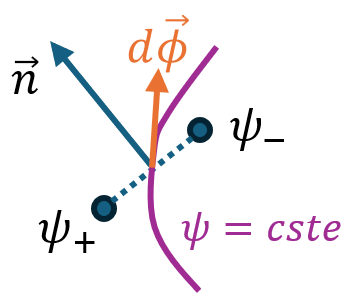



En modélisation planaire, les lignes de champs coïncide avec les lignes de niveaux du potentiel vecteur $A_z$.
En effet:
$$ d\phi = (a(x+dx) - a(x)) L = (a(x) + \frac{da}{dx} dx - a(x)) L = L da = d(L a) $$

Un flux élémentaire s'obtient par différenciation du potentiel vecteur

In [44]:
def DrawFluxLines(a, vec, type = "planar", mesh = mesh):
    if type == "planar":
        BandFluxLines =  vec / Norm(vec) * a
    elif type == "cylindrical":
        BandFluxLines =  vec / Norm(vec) * a
    Draw(BandFluxLines, mesh,
         vectors={"grid_size" : 50, "offset" : 0.5 }, order = 20)
    
DrawFluxLines(sol_planar, curl(sol_planar))

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

______
# Modélisation axisymétrique

## a) Formulation naïve
Ne marche que pour un ordre > 1.

In [45]:
fes_axi = H1(mesh, order = 2, dirichlet = "ext|axis")
Kaxi = BilinearForm(fes_axi)
Kaxi += curl(v, "cylindrical") * 1/mu0 * curl(a, "cylindrical") * 2*pi*x*  dx

faxi =LinearForm(fes_axi)
faxi += j*v * 2*pi*x * dx("coil")

Kaxi.Assemble()
faxi.Assemble()

sol_axi = GridFunction(fes_axi)
sol_axi.vec.data = Kaxi.mat.Inverse(fes_axi.FreeDofs()) * faxi.vec

On se rend compte que les lignes de niveau du potentiel vecteur et les lignes de flux ne coïncident plus! C'est lié à la transformation de l'espace.

In [46]:
DrawFluxLines(sol_axi, curl(sol_axi, "cylindrical"))

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Pour suivre les lignes de flux, il faut 

## b) En tenant compte de l'intégration

In [47]:
from ngsolve.comp import IntegrationRuleSpace 

fes_axi2 = H1(mesh, order = 1, dirichlet = "ext|axis")
quadratureOrder = fes_axi2.globalorder * 2
intrules = IntegrationRuleSpace(mesh, order = quadratureOrder).GetIntegrationRules()


In [48]:
Kaxi2 = BilinearForm(fes_axi2)
Kaxi2 += curl(v, "cylindrical") * 1/mu0 * curl(a, "cylindrical") * 2*pi*x*  dx(intrules = intrules)

faxi2 =LinearForm(fes_axi2)
faxi2 += j*v * 2*pi*x * dx("coil",intrules = intrules)

Kaxi2.Assemble()
faxi2.Assemble()

sol_axi2 = GridFunction(fes_axi2)
sol_axi2.vec.data = Kaxi2.mat.Inverse(fes_axi2.FreeDofs()) * faxi2.vec
Draw(2*pi*x*sol_axi2, mesh)
Draw(curl(sol_axi2, "cylindrical"), mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

# 2) Formulations stables